In [1]:
import torch
from torch import nn
from torch import optim
import torchvision
from torchvision import models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [ ]:
def mean_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    for images, _ in loader:
        image_count_in_a_batch = images.size(0)
        images = images.view(image_count_in_a_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += image_count_in_a_batch

    mean /= total_images_count
    std  /= total_images_count
    return mean , std , total_images_count

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_path = r"C:\Users\azaru\Azar documents\Data science - GUVI\Final project\Project - 2\data\train"
test_path = r"C:\Users\azaru\Azar documents\Data science - GUVI\Final project\Project - 2\data\test"


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5194], std=[0.2067])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.51], std=[0.20])
])


train_dataset = ImageFolder(root=train_path, transform=train_transform)
test_dataset = ImageFolder(root=test_path, transform=test_transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


class EDM30LayerCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EDM30LayerCNN, self).__init__()

        layers = []
        in_channels = 1
        out_channels = 16

        
        for i in range(15):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())

            if i % 3 == 0:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            
            in_channels = out_channels
            if out_channels < 256: 
                out_channels *= 2

        self.conv_layers = nn.Sequential(*layers)

        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        
        self.fc = nn.Linear(256, num_classes)  

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = EDM30LayerCNN(num_classes=7)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epoch = 100
for i in range(epoch):
    model.train()
    running_loss = 0
    for inputs, targets in train_loader:  
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if i % 10 == 0:
        print(f'{i}/{epoch} Loss: {running_loss / len(train_loader)}')
        
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        _, prediction = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (prediction == targets).sum().item()

accuracy = correct / total
print(f"Test Accuracy : {accuracy:.4f}")


0/100 Loss: 1.8930754959583282
10/100 Loss: 1.1486088466644286
20/100 Loss: 0.21412832096219062
30/100 Loss: 0.04680375810712576
40/100 Loss: 0.008425311579485424
50/100 Loss: 0.012418872400885447
60/100 Loss: 0.0031074282854388004
70/100 Loss: 0.0026154657570441487
80/100 Loss: 0.0024045000107435046
90/100 Loss: 0.008164653498679399
Test Accuracy : 0.5358


In [2]:
torch.save(model.state_dict(),'edm30_model.pth')

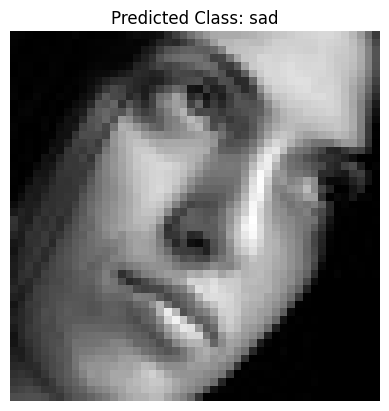

In [11]:
import torch
from torch import nn
from torchvision import transforms 
from torchvision.transforms import ToTensor
from PIL import Image 
import matplotlib.pyplot as plt


classes = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]



model = EDM30LayerCNN(num_classes=len(classes))


state_dict = torch.load('edm30_model.pth')
model.load_state_dict(state_dict, strict=False)


image_path = r"C:\Users\azaru\Azar documents\Data science - GUVI\Final project\Project - 2\sample images\sad.jpg"
image_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    ToTensor(),
    transforms.Normalize(mean=[0.5194], std=[0.2067])
])


def predict_model(model, image_transforms, image_path, classes):
    model.eval()  
    image = Image.open(image_path)
    transformed_image = image_transforms(image).float()
    transformed_image = transformed_image.unsqueeze(0)  
    
    with torch.no_grad():
        output = model(transformed_image)
        _, predicted = torch.max(output.data, 1)

    predicted_class = classes[predicted.item()]
    

    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis('off')
    plt.show()


predict_model(model, image_transforms, image_path, classes)
